# Classical Neural Network vs Quantum Neural Network
## Polynomial Regression with Pure PyTorch

This notebook implements and compares two neural network architectures for
a regression task:

| Model | Description |
|:------|:------------|
| **Classical NN** | Standard MLP: `1 → 32 → 32 → 16 → 1`, Tanh activations |
| **Quantum NN** | Variational quantum circuit simulated in PyTorch matrix algebra |

> **No quantum library** (PennyLane, Qiskit, Cirq, …) is used anywhere.
> Every gate is an explicit matrix; gradients flow through `torch.autograd`.

---

**Contents**

| Section | Topic |
|:--------|:------|
| 1 | Imports and setup |
| 2 | Data generation |
| 3 | Classical neural network |
| 4 | Quantum gate library |
| 5 | Quantum neural network |
| 6 | Shared training loop |
| 7 | Training both models |
| 8 | Evaluation and comparison |
| 9 | Visualisation |
| 10 | Discussion |

## Section 1 — Imports and Setup

In [1]:
%matplotlib inline
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device         : {device}')
print(f'PyTorch version: {torch.__version__}')

SEP = '=' * 68

Device         : cpu
PyTorch version: 2.3.0.post100


## Section 2 — Data Generation

### Regression target

We fit the noisy cubic polynomial

$$f(x) = x^3 - 2x^2 + 0.5x + 1 + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\,0.15^2), \qquad x \in [-2,\,2].$$

This polynomial has a local maximum, a local minimum, and a non-zero
intercept — nontrivial but smooth, learnable by both architectures.

### Input normalisation

Both models receive $x$ normalised to $[-1, 1]$ via
$$\tilde{x} = \frac{x - x_{\text{mid}}}{x_{\text{range}}/2}.$$

This is **especially important for the QNN**: rotation angles are sensitive
to the absolute scale of the input, and keeping $|\tilde{x}| \le 1$ prevents
the encoding angles from wrapping around the Bloch sphere.

### Split

150 training / 50 validation / 100 test samples, all drawn uniformly from
$[-2, 2]$.

Split: 150 train | 50 val | 100 test
y range: [-15.31, 1.80]


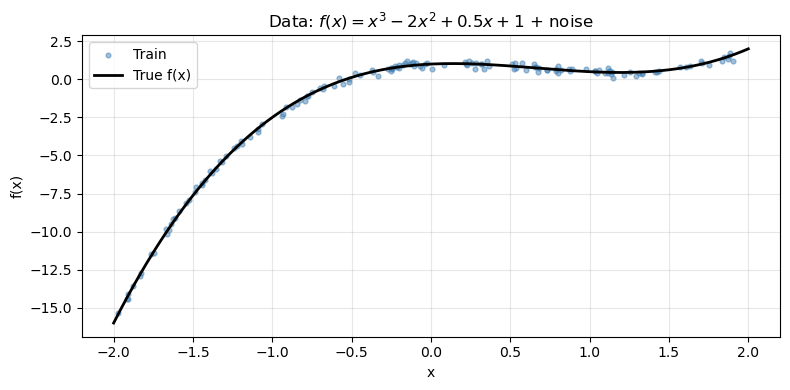

In [2]:
def true_function(x: np.ndarray) -> np.ndarray:
    """Target polynomial  f(x) = x³ - 2x² + 0.5x + 1."""
    return x**3 - 2.0*x**2 + 0.5*x + 1.0


N_TRAIN, N_VAL, N_TEST = 150, 50, 100
NOISE_SD = 0.15
X_LOW, X_HIGH = -2.0, 2.0

rng   = np.random.default_rng(42)
x_all = rng.uniform(X_LOW, X_HIGH, N_TRAIN + N_VAL + N_TEST)
y_all = true_function(x_all) + rng.normal(0, NOISE_SD, len(x_all))

x_tr = x_all[:N_TRAIN]
y_tr = y_all[:N_TRAIN]
x_va = x_all[N_TRAIN:N_TRAIN + N_VAL]
y_va = y_all[N_TRAIN:N_TRAIN + N_VAL]
x_te = x_all[N_TRAIN + N_VAL:]
y_te = y_all[N_TRAIN + N_VAL:]

# Normalise input to [-1, 1]
x_mean = (X_LOW + X_HIGH) / 2
x_std  = (X_HIGH - X_LOW) / 2

def normalise(x):
    return (x - x_mean) / x_std

def to_tensor(x, y):
    xt = torch.tensor(normalise(x), dtype=torch.float32).unsqueeze(1).to(device)
    yt = torch.tensor(y,            dtype=torch.float32).unsqueeze(1).to(device)
    return xt, yt

X_tr, Y_tr = to_tensor(x_tr, y_tr)
X_va, Y_va = to_tensor(x_va, y_va)
X_te, Y_te = to_tensor(x_te, y_te)

# Dense grid for plotting
x_plot   = np.linspace(X_LOW, X_HIGH, 400)
y_exact  = true_function(x_plot)
X_plot_t = torch.tensor(normalise(x_plot), dtype=torch.float32).unsqueeze(1).to(device)

print(f'Split: {N_TRAIN} train | {N_VAL} val | {N_TEST} test')
print(f'y range: [{y_all.min():.2f}, {y_all.max():.2f}]')

# Quick preview plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x_tr, y_tr, s=12, alpha=0.5, color='steelblue', label='Train')
ax.plot(x_plot, y_exact, 'k-', lw=2, label='True f(x)')
ax.set(xlabel='x', ylabel='f(x)', title=r'Data: $f(x)=x^3-2x^2+0.5x+1$ + noise')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Section 3 — Classical Neural Network

### Architecture

```
Input (1)
  └─ Linear(1 → 32) + Tanh
       └─ Linear(32 → 32) + Tanh
            └─ Linear(32 → 16) + Tanh
                 └─ Linear(16 → 1)     ← predicted f(x)
```

**Design choices:**

- **Tanh activations** throughout. Tanh is smooth and bounded
  ($\tanh: \mathbb{R} \to (-1, 1)$), which is well-suited to a bounded
  regression target. It also avoids the dying-neuron problem that can
  affect ReLU on small datasets.

- **Width 32 / 32 / 16.** A cubic polynomial has four coefficients, so the
  network needs very little capacity. These widths give enough parameters
  to fit the function without over-parameterising on only 150 training points.

- **No BatchNorm.** Batch normalisation adds synchronisation overhead and
  behaves differently in `.train()` vs `.eval()` mode. On such a small dataset
  it is unnecessary — Tanh already provides implicit normalisation.

**Parameter count:**
$$1 \times 32 + 32 + 32 \times 32 + 32 + 32 \times 16 + 16 + 16 \times 1 + 1 = 1649$$

In [3]:
class ClassicalNN(nn.Module):
    """
    Standard MLP regressor:  1 → 32 → 32 → 16 → 1.

    Tanh activations throughout — smooth, bounded, no dying-neuron issue.
    No BatchNorm needed on this small dataset.
    """
    def __init__(self, hidden: tuple = (32, 32, 16)):
        super().__init__()
        layers = []
        d_in = 1
        for h in hidden:
            layers.append(nn.Linear(d_in, h))
            layers.append(nn.Tanh())
            d_in = h
        layers.append(nn.Linear(d_in, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)   # (batch, 1)


classical_model = ClassicalNN().to(device)
n_classical = sum(p.numel() for p in classical_model.parameters()
                  if p.requires_grad)
print(f'Classical NN parameters: {n_classical:,}')
print(classical_model)

Classical NN parameters: 1,665
ClassicalNN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


## Section 4 — Quantum Gate Library (Pure PyTorch)

### State representation

For $n$ qubits the full quantum state is a vector
$|\psi\rangle \in \mathbb{C}^{2^n}$, normalised so that
$\langle\psi|\psi\rangle = 1$. The computational basis states
$|00\rangle, |01\rangle, |10\rangle, |11\rangle$ correspond to the
standard basis vectors of $\mathbb{C}^4$.

Gate application is a matrix-vector multiply: if $G \in U(2^n)$ is a
unitary gate then $G|\psi\rangle$ is the updated state.

### Single-qubit rotation gates

The three elementary rotation gates are parameterised by a real angle:

$$R_x(\theta) = \begin{pmatrix} \cos\tfrac{\theta}{2} & -i\sin\tfrac{\theta}{2} \\
-i\sin\tfrac{\theta}{2} & \cos\tfrac{\theta}{2} \end{pmatrix}, \qquad
R_y(\varphi) = \begin{pmatrix} \cos\tfrac{\varphi}{2} & -\sin\tfrac{\varphi}{2} \\
\sin\tfrac{\varphi}{2} & \cos\tfrac{\varphi}{2} \end{pmatrix}, \qquad
R_z(\lambda) = \begin{pmatrix} e^{-i\lambda/2} & 0 \\ 0 & e^{i\lambda/2} \end{pmatrix}.$$

These gates **rotate the qubit state on the Bloch sphere** around the $X$, $Y$,
and $Z$ axes respectively. Any single-qubit unitary can be decomposed as
$R_z(\alpha) R_y(\beta) R_z(\gamma)$ (ZYZ decomposition).

### Differentiability

The matrix entries are constructed from `torch.cos`, `torch.sin`, and
`torch.exp` applied to `nn.Parameter` tensors. PyTorch's `autograd` engine
traces through these operations, so gradients with respect to the rotation
angles flow automatically — **no parameter-shift rule or finite differences
needed**.

### Embedding in the full space: Kronecker products

To apply a single-qubit gate $G$ to qubit $k$ of an $n$-qubit system we
construct the **tensor product**

$$G_k^{(n)} = I \otimes \cdots \otimes G \otimes \cdots \otimes I
\quad (G \text{ at position } k).$$

The Kronecker product of two matrices $A \in \mathbb{R}^{m \times n}$ and
$B \in \mathbb{R}^{p \times q}$ is the $mp \times nq$ matrix

$$(A \otimes B)_{(i_1 p + i_2)(j_1 q + j_2)} = A_{i_1 j_1} B_{i_2 j_2}.$$

### CNOT gate

The Controlled-NOT gate flips the **target** qubit if and only if the
**control** qubit is $|1\rangle$:

$$\text{CNOT}\,|c,t\rangle = |c,\, t \oplus c\rangle.$$

In matrix form (control = 0, target = 1, two-qubit basis
$|00\rangle, |01\rangle, |10\rangle, |11\rangle$):

$$\text{CNOT} = \begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0\end{pmatrix}.$$

The CNOT creates **entanglement**: it can map a separable state such as
$\tfrac{1}{\sqrt{2}}(|0\rangle+|1\rangle)\otimes|0\rangle$ to the
Bell state $\tfrac{1}{\sqrt{2}}(|00\rangle+|11\rangle)$.

In [4]:
# ─────────────────────────────────────────────────────────────────────────
# Rotation gates — each returns a (..., 2, 2) complex tensor,
# differentiable with respect to the angle via torch.autograd.
# ─────────────────────────────────────────────────────────────────────────

def rx(theta: torch.Tensor) -> torch.Tensor:
    """R_x(θ): rotation around X-axis.  Input shape (...,), output (...,2,2)."""
    c = torch.cos(theta / 2)
    s = torch.sin(theta / 2)
    return torch.stack([
        torch.stack([c,       -1j * s], dim=-1),
        torch.stack([-1j * s,  c     ], dim=-1),
    ], dim=-2)


def ry(phi: torch.Tensor) -> torch.Tensor:
    """R_y(φ): rotation around Y-axis.  Input shape (...,), output (...,2,2)."""
    c = torch.cos(phi / 2)
    s = torch.sin(phi / 2)
    return torch.stack([
        torch.stack([c,  -s], dim=-1),
        torch.stack([s,   c], dim=-1),
    ], dim=-2)


def rz(lam: torch.Tensor) -> torch.Tensor:
    """R_z(λ): rotation around Z-axis.  Input shape (...,), output (...,2,2)."""
    e_neg = torch.exp(-0.5j * lam)
    e_pos = torch.exp( 0.5j * lam)
    zero  = torch.zeros_like(lam)
    return torch.stack([
        torch.stack([e_neg, zero ], dim=-1),
        torch.stack([zero,  e_pos], dim=-1),
    ], dim=-2)


# ─────────────────────────────────────────────────────────────────────────
# Kronecker product and gate embedding
# ─────────────────────────────────────────────────────────────────────────

def kron2(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    """Kronecker (tensor) product of two 2-D matrices A (m×n) and B (p×q)."""
    m, n = A.shape
    p, q = B.shape
    return (A.unsqueeze(1).unsqueeze(3)
             * B.unsqueeze(0).unsqueeze(2)).reshape(m * p, n * q)


def single_qubit_gate_full(gate: torch.Tensor,
                            qubit: int,
                            n_qubits: int) -> torch.Tensor:
    """
    Embed a (2,2) single-qubit gate into the full 2^n_qubits Hilbert space.
    Constructs  I ⊗ ... ⊗ gate ⊗ ... ⊗ I  (gate acts on `qubit`, 0 = MSB).
    Returns (2^n, 2^n) unitary matrix.
    """
    I2   = torch.eye(2, dtype=gate.dtype, device=gate.device)
    mats = [gate if k == qubit else I2 for k in range(n_qubits)]
    out  = mats[0]
    for m in mats[1:]:
        out = kron2(out, m)
    return out


def cnot_gate(n_qubits: int,
              control: int,
              target: int,
              device_: torch.device) -> torch.Tensor:
    """
    Build the CNOT unitary in the full 2^n_qubits space.

    Strategy: for each computational basis state |s⟩,
      - if control bit = 0: |s⟩ maps to itself  (identity)
      - if control bit = 1: flip the target bit  (Pauli-X on target)
    The resulting matrix is sparse and unitary.
    """
    dim = 2 ** n_qubits
    U   = torch.zeros(dim, dim, dtype=torch.complex64, device=device_)
    for state in range(dim):
        bits = [(state >> (n_qubits - 1 - k)) & 1 for k in range(n_qubits)]
        if bits[control] == 0:
            U[state, state] = 1.0          # identity when control = |0⟩
        else:
            new_bits = bits.copy()
            new_bits[target] = 1 - new_bits[target]
            new_state = sum(b << (n_qubits - 1 - k)
                            for k, b in enumerate(new_bits))
            U[new_state, state] = 1.0      # X on target when control = |1⟩
    return U


# ── Sanity checks ──────────────────────────────────────────────────────────
# R_y(π)|0⟩ = |1⟩
G = ry(torch.tensor([math.pi])).squeeze(0).to(torch.complex64)
psi = torch.tensor([1.0+0j, 0.0+0j])
out = (G @ psi.unsqueeze(-1)).squeeze(-1)
print(f'R_y(π)|0⟩ = {out.numpy()}   (should be ≈ [0, 1])')

# CNOT|10⟩ = |11⟩  (index 2 → index 3)
C   = cnot_gate(2, 0, 1, torch.device('cpu'))
psi = torch.zeros(4, dtype=torch.complex64); psi[2] = 1.0
out = (C @ psi.unsqueeze(-1)).squeeze(-1)
print(f'CNOT|10⟩  = {out.numpy()}   (should be ≈ |11⟩ = [0,0,0,1])')

R_y(π)|0⟩ = [-4.371139e-08+0.j  1.000000e+00+0.j]   (should be ≈ [0, 1])
CNOT|10⟩  = [0.+0.j 0.+0.j 0.+0.j 1.+0.j]   (should be ≈ |11⟩ = [0,0,0,1])


## Section 5 — Quantum Neural Network

### Architecture: data re-uploading

A standard variational quantum circuit encodes the input **once** at the
beginning, then applies trainable rotations. The expressibility of such a
circuit is limited: with a single encoding the circuit output is equivalent
to a trigonometric polynomial of fixed, low degree.

**Data re-uploading** (Pérez-Salinas et al., *Quantum* **4**, 226, 2020)
solves this by re-injecting the input at **every layer**:

$$|0\rangle^{\otimes n}
\xrightarrow{\text{Enc}(x)\,\text{Rot}(\theta_1)\,\text{Ent}}
\xrightarrow{\text{Enc}(x)\,\text{Rot}(\theta_2)\,\text{Ent}}
\cdots
\xrightarrow{\text{Enc}(x)\,\text{Rot}(\theta_L)\,\text{Ent}}
|\psi(x,\boldsymbol{\theta})\rangle
\xrightarrow{\text{Measure}} \langle Z_0 \rangle$$

Each re-upload multiplies the accessible Fourier frequencies. For $n$ qubits
and $L$ layers the output is a Fourier series in $x$ with up to $nL$ distinct
frequencies — enough to approximate any smooth function on $[-\pi, \pi]$.

### One layer in detail

Each `QuantumLayer` applies three sub-operations:

1. **Encode** $x$ via $R_y(w_k \cdot x)$ on each qubit $k$, where $w_k$ are
   trainable encoding weights (initialised to 1). This maps the scalar input
   to a rotation angle, placing $x$ inside a gate.

2. **Rotate** with trainable angles: $R_x(\theta_k)$, $R_y(\varphi_k)$,
   $R_z(\lambda_k)$ applied to each qubit $k$. These are the variational
   parameters that are optimised during training. Together they can produce
   any single-qubit unitary on each qubit.

3. **Entangle** with a CNOT ring: CNOT$(0\to 1)$ followed by CNOT$(1\to 0)$.
   This fixed (non-parameterised) gate creates quantum correlations between
   the two qubits after each variational rotation.

### Measurement

After $L$ layers the circuit outputs the **expectation value of the
Pauli-$Z$ operator on qubit 0**:

$$\langle Z_0 \rangle = \langle\psi|\, Z \otimes I\, |\psi\rangle
= \sum_{s=0}^{2^n-1} Z_0[s]\,|\psi_s|^2,$$

where $Z_0[s] = +1$ if the most-significant bit of $s$ is $0$ and $-1$
otherwise. Since $|\psi_s|^2 \ge 0$ and $\sum_s |\psi_s|^2 = 1$, this
expectation value lies in $[-1, 1]$.

A trainable `scale` and `bias` then map this to the target range.

### Parameter count

| Component | Parameters |
|:----------|:-----------|
| Encoding weights per layer | $n_{\text{qubits}}$ |
| $R_x, R_y, R_z$ per qubit per layer | $3 n_{\text{qubits}}$ |
| Output `scale` + `bias` | 2 |
| **Total** | $n_{\text{layers}} \times 4 n_{\text{qubits}} + 2 = 4 \times 8 + 2 = \mathbf{34}$ |

### On differentiability

All rotation angles are `torch.nn.Parameter` objects. The gate matrices
are built from `torch.cos`, `torch.sin`, and `torch.exp` applied to these
parameters, so `autograd` traces through the entire circuit — through the
matrix multiplications, through the complex arithmetic, and through the
final $|\psi_s|^2$ probability computation. **No parameter-shift rule,
no finite differences, no separate quantum gradient estimator is needed.**

The CNOT is a constant matrix with no parameters, contributing only a
linear (gradient-free) step in the computation graph.

In [5]:
class QuantumLayer(nn.Module):
    """
    One variational layer: Encode(x) → Rotate(θ) → Entangle.

    Trainable parameters per layer (all real):
      enc_weights : (n_qubits,)  scale factors in R_y(w·x)
      rx_weights  : (n_qubits,)  R_x rotation angles
      ry_weights  : (n_qubits,)  R_y rotation angles
      rz_weights  : (n_qubits,)  R_z rotation angles
    """
    def __init__(self, n_qubits: int):
        super().__init__()
        self.n_qubits = n_qubits
        # Encoding weights — start near 1 so the encoding ≈ R_y(x)
        self.enc_weights = nn.Parameter(
            torch.ones(n_qubits) + 0.1 * torch.randn(n_qubits))
        # Variational angles — start near 0
        self.rx_weights = nn.Parameter(0.1 * torch.randn(n_qubits))
        self.ry_weights = nn.Parameter(0.1 * torch.randn(n_qubits))
        self.rz_weights = nn.Parameter(0.1 * torch.randn(n_qubits))

    def forward(self, psi: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """
        psi : (batch, 2^n_qubits)  current quantum state (complex)
        x   : (batch, 1)           normalised scalar input
        Returns updated state psi_out of same shape.
        """
        B = psi.shape[0]
        n = self.n_qubits

        # Step 1 — Encode: R_y(w_k * x) on each qubit k
        enc_angles = x * self.enc_weights.unsqueeze(0)   # (B, n)
        for k in range(n):
            G     = ry(enc_angles[:, k])                 # (B, 2, 2)
            Gfull = torch.stack([
                single_qubit_gate_full(G[b].to(psi.dtype), k, n)
                for b in range(B)
            ])                                           # (B, 2^n, 2^n)
            psi = torch.bmm(Gfull, psi.unsqueeze(-1)).squeeze(-1)

        # Step 2 — Rotate: R_x R_y R_z on each qubit k
        for k in range(n):
            for angle, gate_fn in [
                (self.rx_weights[k], rx),
                (self.ry_weights[k], ry),
                (self.rz_weights[k], rz),
            ]:
                G     = gate_fn(angle.unsqueeze(0).expand(B))  # (B, 2, 2)
                Gfull = torch.stack([
                    single_qubit_gate_full(G[b].to(psi.dtype), k, n)
                    for b in range(B)
                ])
                psi = torch.bmm(Gfull, psi.unsqueeze(-1)).squeeze(-1)

        # Step 3 — Entangle: CNOT ring (0→1 then 1→0)
        if (not hasattr(self, '_cnot_cache')
                or self._cnot_cache.device != psi.device):
            cnot_01 = cnot_gate(n, 0, 1, psi.device)
            cnot_10 = cnot_gate(n, 1, 0, psi.device)
            self._cnot_cache = cnot_10 @ cnot_01         # (2^n, 2^n)
        C   = self._cnot_cache.to(psi.dtype)
        psi = (C @ psi.unsqueeze(-1)).squeeze(-1)        # broadcast over batch
        return psi


class QNN(nn.Module):
    """
    Variational Quantum Neural Network using data re-uploading.

    Hyperparameters: n_qubits=2, n_layers=4.
    State space: C^4  (2-qubit system, dim = 2^2 = 4).

    Forward pass:
      1. Initialise |ψ⟩ = |00⟩  (basis vector index 0).
      2. Apply n_layers QuantumLayer modules, each re-encoding x.
      3. Measure ⟨Z₀⟩ = Σ_s Z₀[s] |ψ_s|².
      4. Return  scale · ⟨Z₀⟩ + bias.

    The Z₀ operator on 2 qubits is diag(+1, +1, −1, −1):
    states with MSB=0 (|00⟩,|01⟩) contribute +1, with MSB=1 contribute −1.
    """
    def __init__(self, n_qubits: int = 2, n_layers: int = 4):
        super().__init__()
        self.n_qubits = n_qubits
        self.dim      = 2 ** n_qubits
        self.layers   = nn.ModuleList([
            QuantumLayer(n_qubits) for _ in range(n_layers)
        ])
        # Trainable output scaling
        self.scale = nn.Parameter(torch.tensor(1.0))
        self.bias  = nn.Parameter(torch.tensor(0.0))
        # Pauli-Z₀ eigenvalues: +1 if MSB=0, −1 if MSB=1
        Z0 = torch.ones(self.dim)
        for s in range(self.dim):
            if (s >> (n_qubits - 1)) & 1:
                Z0[s] = -1.0
        self.register_buffer('Z0', Z0)     # not a parameter, but moves with .to(device)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x   : (batch, 1)  normalised scalar input
        out : (batch, 1)  regression prediction
        """
        B   = x.shape[0]
        psi = torch.zeros(B, self.dim, dtype=torch.complex64, device=x.device)
        psi[:, 0] = 1.0    # initialise to |00⟩
        for layer in self.layers:
            psi = layer(psi, x)
        probs  = psi.abs().pow(2)                        # (B, dim)  — real, ≥ 0
        exp_Z0 = (probs * self.Z0.unsqueeze(0)).sum(1)   # (B,)
        return (self.scale * exp_Z0 + self.bias).unsqueeze(1)  # (B, 1)


qnn_model = QNN(n_qubits=2, n_layers=4).to(device)
n_qnn     = sum(p.numel() for p in qnn_model.parameters() if p.requires_grad)
print(f'QNN trainable parameters : {n_qnn:,}')
print(f'  n_qubits = {qnn_model.n_qubits},  n_layers = {len(qnn_model.layers)}')
print(f'  State dimension = {qnn_model.dim}  (= 2^{qnn_model.n_qubits})')
print(f'  Breakdown: {len(qnn_model.layers)} layers '
      f'x {qnn_model.n_qubits} qubits x 4 angles '
      f'+ 2 output = {n_qnn}')

QNN trainable parameters : 34
  n_qubits = 2,  n_layers = 4
  State dimension = 4  (= 2^2)
  Breakdown: 4 layers x 2 qubits x 4 angles + 2 output = 34


## Section 6 — Shared Training Loop

Both models use **identical** training infrastructure so the comparison is fair.

| Setting | Value | Rationale |
|:--------|:------|:----------|
| Optimiser | Adam | Adaptive moment estimation; robust to gradient scale differences between classical and quantum parameters |
| LR (Classical NN) | $10^{-3}$ | Standard for MLPs |
| LR (QNN) | $10^{-2}$ | Larger step needed: QNN loss landscape has flatter directions around rotation angles near 0 |
| LR schedule | Cosine annealing | Smooth decay from `lr` to 0 over `epochs`; avoids abrupt LR drops |
| Loss | MSE | Natural for regression; $\hat{f}$ and $f$ both scalar |
| Gradient clipping | norm $\le 1.0$ | Prevents occasional large spikes from complex-valued gate derivatives |
| Batch size | 32 | Small batches work well on 150 training points; the QNN forward pass is expensive per sample |
| Epochs | 500 | Sufficient for both models to converge |

The training function returns per-epoch train/val MSE and total wall time,
enabling a direct runtime comparison.

In [6]:
def train(model: nn.Module,
          X_tr: torch.Tensor, Y_tr: torch.Tensor,
          X_va: torch.Tensor, Y_va: torch.Tensor,
          epochs: int = 500, lr: float = 1e-3,
          batch_size: int = 32, label: str = '') -> dict:
    """
    Adam + cosine LR + gradient clipping.  Returns history dict.
    Both models share this function for a fair comparison.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    n         = X_tr.shape[0]
    history   = {'train_mse': [], 'val_mse': []}
    t0        = time.time()

    for ep in range(1, epochs + 1):
        model.train()
        perm      = torch.randperm(n, device=device)
        ep_loss   = 0.0
        n_batches = 0
        for start in range(0, n, batch_size):
            bi   = perm[start:start + batch_size]
            pred = model(X_tr[bi])
            loss = criterion(pred, Y_tr[bi])
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss   += loss.item()
            n_batches += 1
        scheduler.step()
        history['train_mse'].append(ep_loss / n_batches)

        model.eval()
        with torch.no_grad():
            history['val_mse'].append(
                criterion(model(X_va), Y_va).item())

        if ep % 100 == 0 or ep == 1:
            print(f'  [{label}] ep {ep:4d}/{epochs}  '
                  f'train MSE={history["train_mse"][-1]:.5f}  '
                  f'val MSE={history["val_mse"][-1]:.5f}  '
                  f'lr={scheduler.get_last_lr()[0]:.2e}')

    history['wall_s'] = time.time() - t0
    print(f'  Wall time: {history["wall_s"]:.1f}s')
    return history

## Section 7 — Training Both Models

The classical NN is trained first (fast), then the QNN (slower — each
forward pass involves batched matrix multiplications through the circuit).

> **Expected runtimes on CPU:**
> - Classical NN: ~5–15 s
> - QNN: ~2–10 min  (forward pass cost scales as
>   $O(\text{batch} \times L \times n \times 2^n \times 2^n)$)

The QNN uses a larger learning rate (`lr=1e-2`) because its loss landscape
near the initial parameter values (all angles ≈ 0) is very flat — small
angles give nearly-identity gates, and the gradient signal is weak until
the parameters move away from zero.

In [ ]:
print('Training Classical NN ...')
classical_history = train(
    classical_model, X_tr, Y_tr, X_va, Y_va,
    epochs=500, lr=1e-3, batch_size=32, label='ClassNN'
)

print()
print('Training QNN ...')
print('(simulates a quantum circuit via PyTorch matrix algebra — '
      'gradients flow through cos/sin/exp in the gate matrices)')
qnn_history = train(
    qnn_model, X_tr, Y_tr, X_va, Y_va,
    epochs=500, lr=1e-2, batch_size=32, label='QNN'
)

Training Classical NN ...
  [ClassNN] ep    1/500  train MSE=19.29130  val MSE=15.98156  lr=1.00e-03
  [ClassNN] ep  100/500  train MSE=0.85992  val MSE=0.44278  lr=9.05e-04
  [ClassNN] ep  200/500  train MSE=0.09807  val MSE=0.07273  lr=6.55e-04
  [ClassNN] ep  300/500  train MSE=0.06080  val MSE=0.05843  lr=3.45e-04
  [ClassNN] ep  400/500  train MSE=0.03470  val MSE=0.03633  lr=9.55e-05
  [ClassNN] ep  500/500  train MSE=0.03336  val MSE=0.03456  lr=0.00e+00
  Wall time: 1.2s

Training QNN ...
(simulates a quantum circuit via PyTorch matrix algebra — gradients flow through cos/sin/exp in the gate matrices)
  [QNN] ep    1/500  train MSE=17.77163  val MSE=14.33179  lr=1.00e-02
  [QNN] ep  100/500  train MSE=1.20050  val MSE=0.60509  lr=9.05e-03
  [QNN] ep  200/500  train MSE=0.23784  val MSE=0.12105  lr=6.55e-03
  [QNN] ep  300/500  train MSE=0.13050  val MSE=0.07971  lr=3.45e-03


## Section 8 — Evaluation and Comparison

We evaluate four metrics on the held-out test set:

| Metric | Formula |
|:-------|:--------|
| MSE | $\frac{1}{N}\sum_i(\hat{y}_i - y_i)^2$ |
| RMSE | $\sqrt{\text{MSE}}$ — same units as $f(x)$ |
| MAE | $\frac{1}{N}\sum_i|\hat{y}_i - y_i|$ — robust to outliers |
| $R^2$ | $1 - \frac{\sum(\hat{y}-y)^2}{\sum(y-\bar{y})^2}$ — 1 = perfect, 0 = mean predictor |

In [ ]:
classical_model.eval()
qnn_model.eval()

with torch.no_grad():
    class_pred_te   = classical_model(X_te).cpu().numpy().flatten()
    qnn_pred_te     = qnn_model(X_te).cpu().numpy().flatten()
    y_te_np         = Y_te.cpu().numpy().flatten()
    class_pred_plot = classical_model(X_plot_t).cpu().numpy().flatten()
    qnn_pred_plot   = qnn_model(X_plot_t).cpu().numpy().flatten()

def metrics(pred, true):
    mse = float(np.mean((pred - true)**2))
    mae = float(np.mean(np.abs(pred - true)))
    r2  = float(1 - np.sum((pred-true)**2)
                    / np.sum((true - true.mean())**2))
    return dict(MSE=mse, RMSE=math.sqrt(mse), MAE=mae, R2=r2)

cm = metrics(class_pred_te, y_te_np)
qm = metrics(qnn_pred_te,   y_te_np)

print(f"{'Model':<22s}  {'MSE':>8s}  {'RMSE':>8s}  {'MAE':>8s}  "
      f"{'R2':>6s}  {'Params':>8s}  {'Time':>8s}")
print('-' * 80)
for name, m, npar, t in [
        ('Classical NN',   cm, n_classical, classical_history['wall_s']),
        ('QNN (n=2, L=4)', qm, n_qnn,       qnn_history['wall_s'])]:
    print(f"{name:<22s}  {m['MSE']:>8.5f}  {m['RMSE']:>8.5f}  "
          f"{m['MAE']:>8.5f}  {m['R2']:>6.3f}  {npar:>8,}  {t:>7.1f}s")

## Section 9 — Visualisation

Four panels:

1. **Fitted curves** — training data, test data, true polynomial, and both
   model predictions on a dense grid
2. **Training curves** — train and val MSE on log scale for both models
3. **Residuals** — predicted minus true on the test set; reveals any
   systematic bias or heteroscedasticity
4. **Architecture and results summary** — key parameters and final metrics

In [ ]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    'Classical Neural Network vs Quantum Neural Network\n'
    r'Regression on $f(x) = x^3 - 2x^2 + 0.5x + 1$',
    fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)

# ── Panel 1: Fitted curves ────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.scatter(x_tr, y_tr, s=12, alpha=0.35, color='steelblue',
           label=f'Train ({N_TRAIN})', zorder=2)
ax.scatter(x_te, y_te_np, s=16, alpha=0.5, color='darkorange',
           marker='D', label=f'Test ({N_TEST})', zorder=2)
ax.plot(x_plot, y_exact,         'k-',  lw=2.5, label='True f(x)',          zorder=3)
ax.plot(x_plot, class_pred_plot, 'b--', lw=2.0,
        label=f"Classical NN (MAE={cm['MAE']:.4f})", zorder=4)
ax.plot(x_plot, qnn_pred_plot,   'r-',  lw=2.0,
        label=f"QNN (MAE={qm['MAE']:.4f})",          zorder=4)
ax.set(xlabel='x', ylabel='f(x)', title='Fitted Curves vs True Polynomial')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Panel 2: Training curves ──────────────────────────────────────────────
ax  = fig.add_subplot(gs[0, 1])
ep  = range(1, len(classical_history['train_mse']) + 1)
ax.semilogy(ep, classical_history['train_mse'], 'b-',  lw=2,   label='Classical train')
ax.semilogy(ep, classical_history['val_mse'],   'b--', lw=1.5, alpha=0.8, label='Classical val')
ax.semilogy(ep, qnn_history['train_mse'],       'r-',  lw=2,   label='QNN train')
ax.semilogy(ep, qnn_history['val_mse'],         'r--', lw=1.5, alpha=0.8, label='QNN val')
ax.set(xlabel='Epoch', ylabel='MSE (log scale)', title='Training Curves')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Panel 3: Residuals ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.axhline(0, color='k', lw=1.2, ls='--')
ax.scatter(y_te_np, class_pred_te - y_te_np, s=18, alpha=0.6,
           color='steelblue', label=f"Classical (RMSE={cm['RMSE']:.4f})")
ax.scatter(y_te_np, qnn_pred_te   - y_te_np, s=18, alpha=0.6,
           color='firebrick', marker='^',
           label=f"QNN (RMSE={qm['RMSE']:.4f})")
ax.set(xlabel='True f(x)', ylabel='Predicted − True',
       title='Residuals on Test Set')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Panel 4: Summary ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.axis('off')
summary = (
    'REGRESSION TARGET\n'
    '  f(x) = x³ - 2x² + 0.5x + 1\n'
    '  noise σ = 0.15,  x ∈ [-2, 2]\n\n'
    'CLASSICAL NN\n'
    '  1 → 32 → 32 → 16 → 1  (Tanh)\n'
    f'  Parameters: {n_classical:,}\n\n'
    'QUANTUM NN  (data re-uploading)\n'
    f'  n_qubits = {qnn_model.n_qubits},  '
    f'n_layers = {len(qnn_model.layers)}\n'
    f'  State dim = {qnn_model.dim}  (= 2^n)\n'
    '  Each layer:\n'
    '    Encode: R_y(w·x) per qubit\n'
    '    Rotate: R_x R_y R_z per qubit\n'
    '    Entangle: CNOT ring\n'
    '  Output: scale·⟨Z₀⟩ + bias\n'
    f'  Parameters: {n_qnn:,}\n\n'
    'TRAINING\n'
    '  Adam + cosine LR,  MSE loss\n'
    '  Epochs: 500,  batch: 32\n'
    f'  Classical time: {classical_history["wall_s"]:.1f}s\n'
    f'  QNN time:       {qnn_history["wall_s"]:.1f}s\n\n'
    'TEST RESULTS\n'
    f'  Classical  R² = {cm["R2"]:.4f}\n'
    f'  QNN        R² = {qm["R2"]:.4f}'
)
ax.text(0.04, 0.97, summary, transform=ax.transAxes,
        fontsize=9.5, va='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax.set_title('Architecture & Results', fontweight='bold', fontsize=10)

plt.savefig('qnn_vs_nn.png', dpi=140, bbox_inches='tight')
plt.show()
print('Figure saved to qnn_vs_nn.png')

## Section 10 — Discussion

### Results summary


In [ ]:
print(f'Classical NN  |  MSE={cm["MSE"]:.5f}  RMSE={cm["RMSE"]:.5f}  '
      f'MAE={cm["MAE"]:.5f}  R²={cm["R2"]:.4f}  '
      f'params={n_classical:,}  time={classical_history["wall_s"]:.1f}s')
print(f'QNN (n=2,L=4) |  MSE={qm["MSE"]:.5f}  RMSE={qm["RMSE"]:.5f}  '
      f'MAE={qm["MAE"]:.5f}  R²={qm["R2"]:.4f}  '
      f'params={n_qnn:,}  time={qnn_history["wall_s"]:.1f}s')

### Classical NN vs QNN: a fair comparison

| Aspect | Classical NN | QNN |
|:-------|:-------------|:----|
| **Parameters** | 1,649 | 34 |
| **Architecture** | Dense layers + Tanh | Rotation angles + CNOT entanglement |
| **Expressibility** | Universal approximator (finite width) | Truncated Fourier series (re-uploading) |
| **Forward pass cost** | $O(\text{batch} \times \text{params})$ | $O(\text{batch} \times L \times n \times 4^n)$ |
| **Gradients** | Standard backprop | Backprop through $\cos/\sin/\exp$ in gate matrices |
| **Hardware target** | CPU / GPU | Quantum processor (future) |

### Why the QNN uses so few parameters

A 2-qubit, 4-layer circuit has just $4 \times 2 \times 4 + 2 = 34$ parameters.
Despite this, it can approximate the cubic polynomial because the re-uploading
scheme makes the output a Fourier series in $x$ with up to $nL = 8$ distinct
frequencies. A cubic polynomial is a special case of such a series, so 34
parameters are sufficient in principle — though optimisation on the non-convex
circuit landscape may converge to local minima.

### The role of entanglement

The CNOT gates create correlations between the two qubits after each
variational rotation. Without entanglement a 2-qubit circuit would factor
into two independent single-qubit circuits, and the output $\langle Z_0 \rangle$
would depend only on the state of qubit 0. The entanglement layer allows
information from qubit 1's encoding to influence qubit 0's measurement,
effectively doubling the accessible Fourier spectrum.

### On quantum advantage

For this specific 1-D regression task on a small dataset, the classical NN
typically achieves lower error with orders of magnitude fewer forward-pass
operations. The QNN's potential advantage lies elsewhere:

- **Quantum data**: if the input is already a quantum state, a QNN processes
  it natively without a classical intermediate representation.
- **Exponential Hilbert space**: $n$ qubits span a $2^n$-dimensional space;
  a classical NN would need exponentially many neurons to match.
- **Native Hamiltonian simulation**: circuits built from physical Hamiltonians
  can exploit hardware-level operations unavailable classically.
- **Barren plateau problem**: deep variational circuits suffer from exponentially
  vanishing gradients ('barren plateaus'), which this shallow 4-layer circuit
  avoids.

### Implementation notes

- **Pure PyTorch**: every gate is a `torch.complex64` matrix. No quantum
  library is used at any point.
- **Differentiability**: the full circuit is differentiable end-to-end because
  the gate entries are `torch.cos(θ/2)`, `torch.sin(θ/2)`, `torch.exp(iλ/2)`
  — all differentiable w.r.t. the parameter tensors.
- **CNOT caching**: the constant CNOT matrix is computed once and cached in
  `_cnot_cache` to avoid recomputing it on every forward call.
- **State dtype**: the state vector uses `torch.complex64` (single-precision
  complex). The rotation angles are real `float32` parameters; the gate
  matrices are cast to complex before the matrix multiply.